In [29]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from scipy.stats import ttest_ind
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter1d
import statsmodels.api as sm
%run ../functions/Transfer_longitude.ipynb
%run ../functions/Yearly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/mask_land_ocean.ipynb
%run ../functions/Moving_mean.ipynb
%run ../functions/lanczos_filter.ipynb

In [3]:
def preprocess_Tadv(Tadv):
    # Select the data over the Sahara
    Tadv_SD=Tadv.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])

    # Do the lanczos filter
    Tadv_SD_lp=lanczos_filter_xr(
        Tadv_SD, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
    )

    # Drop the nan, multiply by (-1) and convert the unit to K/d
    Med=-Tadv_SD_lp.dropna(dim='time')
    return Med

def preprocess_pot(pot):
    # Select the data over the Sahara
    pot_SD=pot.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])

    # Do the lanczos filter
    pot_SD_lp=lanczos_filter_xr(
        pot_SD, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
    )

    # Drop the nan
    Med=pot_SD_lp.dropna(dim='time')
    return Med

## Read the data

In [64]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Med/'
filename='Tadv.900.direct.nc'
fi=xr.open_dataset(diri+filename)
# ## Transfer the longitude
# fi=central180_to_0(fi)
Tadv=fi.Tadv
Med_Tadv=preprocess_Tadv(Tadv)

filename='pot.900.nc'
fi=xr.open_dataset(diri+filename)
# ## Transfer the longitude
# fi=central180_to_0(fi)
pot=fi.pot
Med_pot=preprocess_pot(pot)

In [65]:
pot

<xarray.DataArray 'pot' (time: 1232, lat: 96, lon: 144)>
[17031168 values with dtype=float32]
Coordinates:
    hour_id  (time) int64 ...
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time     (time) datetime64[ns] 1979-06-01 ... 1979-11-01T21:00:00

In [5]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Car/'
filename='Tadv.900.direct.nc'
fi=xr.open_dataset(diri+filename)
# ## Transfer the longitude
# fi=central180_to_0(fi)
Tadv=fi.Tadv
Car_Tadv=preprocess_Tadv(Tadv)

filename='pot.900.nc'
fi=xr.open_dataset(diri+filename)
# ## Transfer the longitude
# fi=central180_to_0(fi)
pot=fi.pot
Car_pot=preprocess_pot(pot)

In [6]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Ind/'
filename='Tadv.900.direct.nc'
fi=xr.open_dataset(diri+filename)
# ## Transfer the longitude
# fi=central180_to_0(fi)
Tadv=fi.Tadv
Ind_Tadv=preprocess_Tadv(Tadv)

filename='pot.900.nc'
fi=xr.open_dataset(diri+filename)
# ## Transfer the longitude
# fi=central180_to_0(fi)
pot=fi.pot
Ind_pot=preprocess_pot(pot)

filename='TTEND_TOT_theta.900.nc'
fi=xr.open_dataset(diri+filename)
TTEND_TOT_theta=fi.TTEND_TOT_theta

In [7]:
TTEND_TOT_theta_SD=TTEND_TOT_theta.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])

In [8]:
TTEND_TOT_theta_SD_lp=lanczos_filter_xr(
    TTEND_TOT_theta_SD, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
)

In [9]:
diri='/zhoulab_rit/lzhuo/data/Modelling/'
filename='snr_Ind.900.nc'
fi=xr.open_dataset(diri+filename)
snr_Ind=fi.snr

filename='snr_Med.900.nc'
fi=xr.open_dataset(diri+filename)
snr_Med=fi.snr

filename='snr_Car.900.nc'
fi=xr.open_dataset(diri+filename)
snr_Car=fi.snr

In [10]:
snr_Ind_nonan=snr_Ind.sel(time=Ind_pot.time)
snr_Med_nonan=snr_Med.sel(time=Med_pot.time)
snr_Car_nonan=snr_Car.sel(time=Car_pot.time)

In [11]:
cond=snr_Ind_nonan>1
Ind_pot_sample=Ind_pot.where(cond).dropna(dim='time')

cond=snr_Med_nonan>1
Med_pot_sample=Med_pot.where(cond).dropna(dim='time')

cond=snr_Car_nonan>1
Car_pot_sample=Car_pot.where(cond).dropna(dim='time')

In [12]:
cond=snr_Ind_nonan>1
Ind_Tadv_sample=Ind_Tadv.where(cond).dropna(dim='time')

cond=snr_Med_nonan>1
Med_Tadv_sample=Med_Tadv.where(cond).dropna(dim='time')

cond=snr_Car_nonan>1
Car_Tadv_sample=Car_Tadv.where(cond).dropna(dim='time')

In [13]:
TTEND_TOT_theta_SD_lp_nonan=TTEND_TOT_theta_SD_lp.sel(time=Ind_pot.time)
TTEND_TOT_theta_SD_lp_nonan

<xarray.DataArray 'TTEND_TOT_theta' (time: 1072)>
array([-2.76866444e-06, -2.85646648e-06, -2.93758305e-06, ...,
        3.77121544e-06,  3.87216163e-06,  3.97047936e-06])
Coordinates:
    hour_id  (time) int64 ...
  * time     (time) datetime64[ns] 1979-06-11 ... 1979-10-22T21:00:00

In [14]:
snr_Ind_nonan

<xarray.DataArray 'snr' (time: 1072)>
array([0.809808, 0.838009, 0.867756, ..., 1.662778, 1.584954, 1.510523])
Coordinates:
    hour_id  (time) int64 ...
  * time     (time) datetime64[ns] 1979-06-11 ... 1979-10-22T21:00:00

In [15]:
Ind_Tadv

<xarray.DataArray 'Tadv' (time: 1072)>
array([-1.01484834e-05, -1.03577077e-05, -1.05560005e-05, ...,
        8.48035500e-06,  8.56812526e-06,  8.65031011e-06])
Coordinates:
    hour_id  (time) int64 ...
  * time     (time) datetime64[ns] 1979-06-11 ... 1979-10-22T21:00:00

In [16]:
def total_frac3(ttend,snr,dadv):
    ## For Ind
    # masks
    cold = ttend < 0
    E = snr > 1
#     A = dadv < 0

    # total positive cooling (denominator)
    total_cold = ttend.where(cold & E).sum("time", skipna=True)

    # positive warming that occurs when (SNR>1) AND (ΔAdv>0) (numerator)
#     cold_EA = dtheta.where(cold & E & A).sum("time", skipna=True)
#     cold_EA = dtheta.where(cold & E ).sum("time", skipna=True)
    cold_EA = dadv.where(cold & E).sum("time", skipna=True)
#     cold_EA = dtheta.where(E&A).sum("time", skipna=True)

    # contribution fraction
    contribution_EA = (cold_EA / total_cold).rename("contribution_SNRgt1_and_dadvgt0")

#     contribution_EA
    
    return total_cold,cold_EA,contribution_EA

total_cold, cold_EA,con= total_frac3(TTEND_TOT_theta_SD_lp_nonan,snr_Ind_nonan,Ind_Tadv)

total_cold

<xarray.DataArray 'TTEND_TOT_theta' ()>
array(-0.00046762)

In [17]:
cold_EA

<xarray.DataArray 'Tadv' ()>
array(-0.00128361)

(array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 array([-0.50128361, -0.40128361, -0.30128361, -0.20128361, -0.10128361,
        -0.00128361,  0.09871639,  0.19871639,  0.29871639,  0.39871639,
         0.49871639]),
 <BarContainer object of 10 artists>)

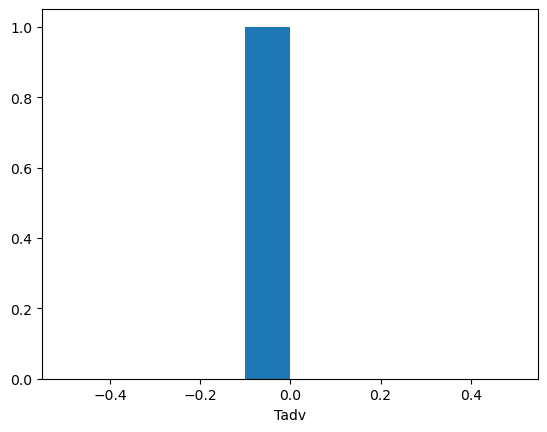

In [18]:
cold_EA.plot()

Text(0.0, 1.0, '(a)')

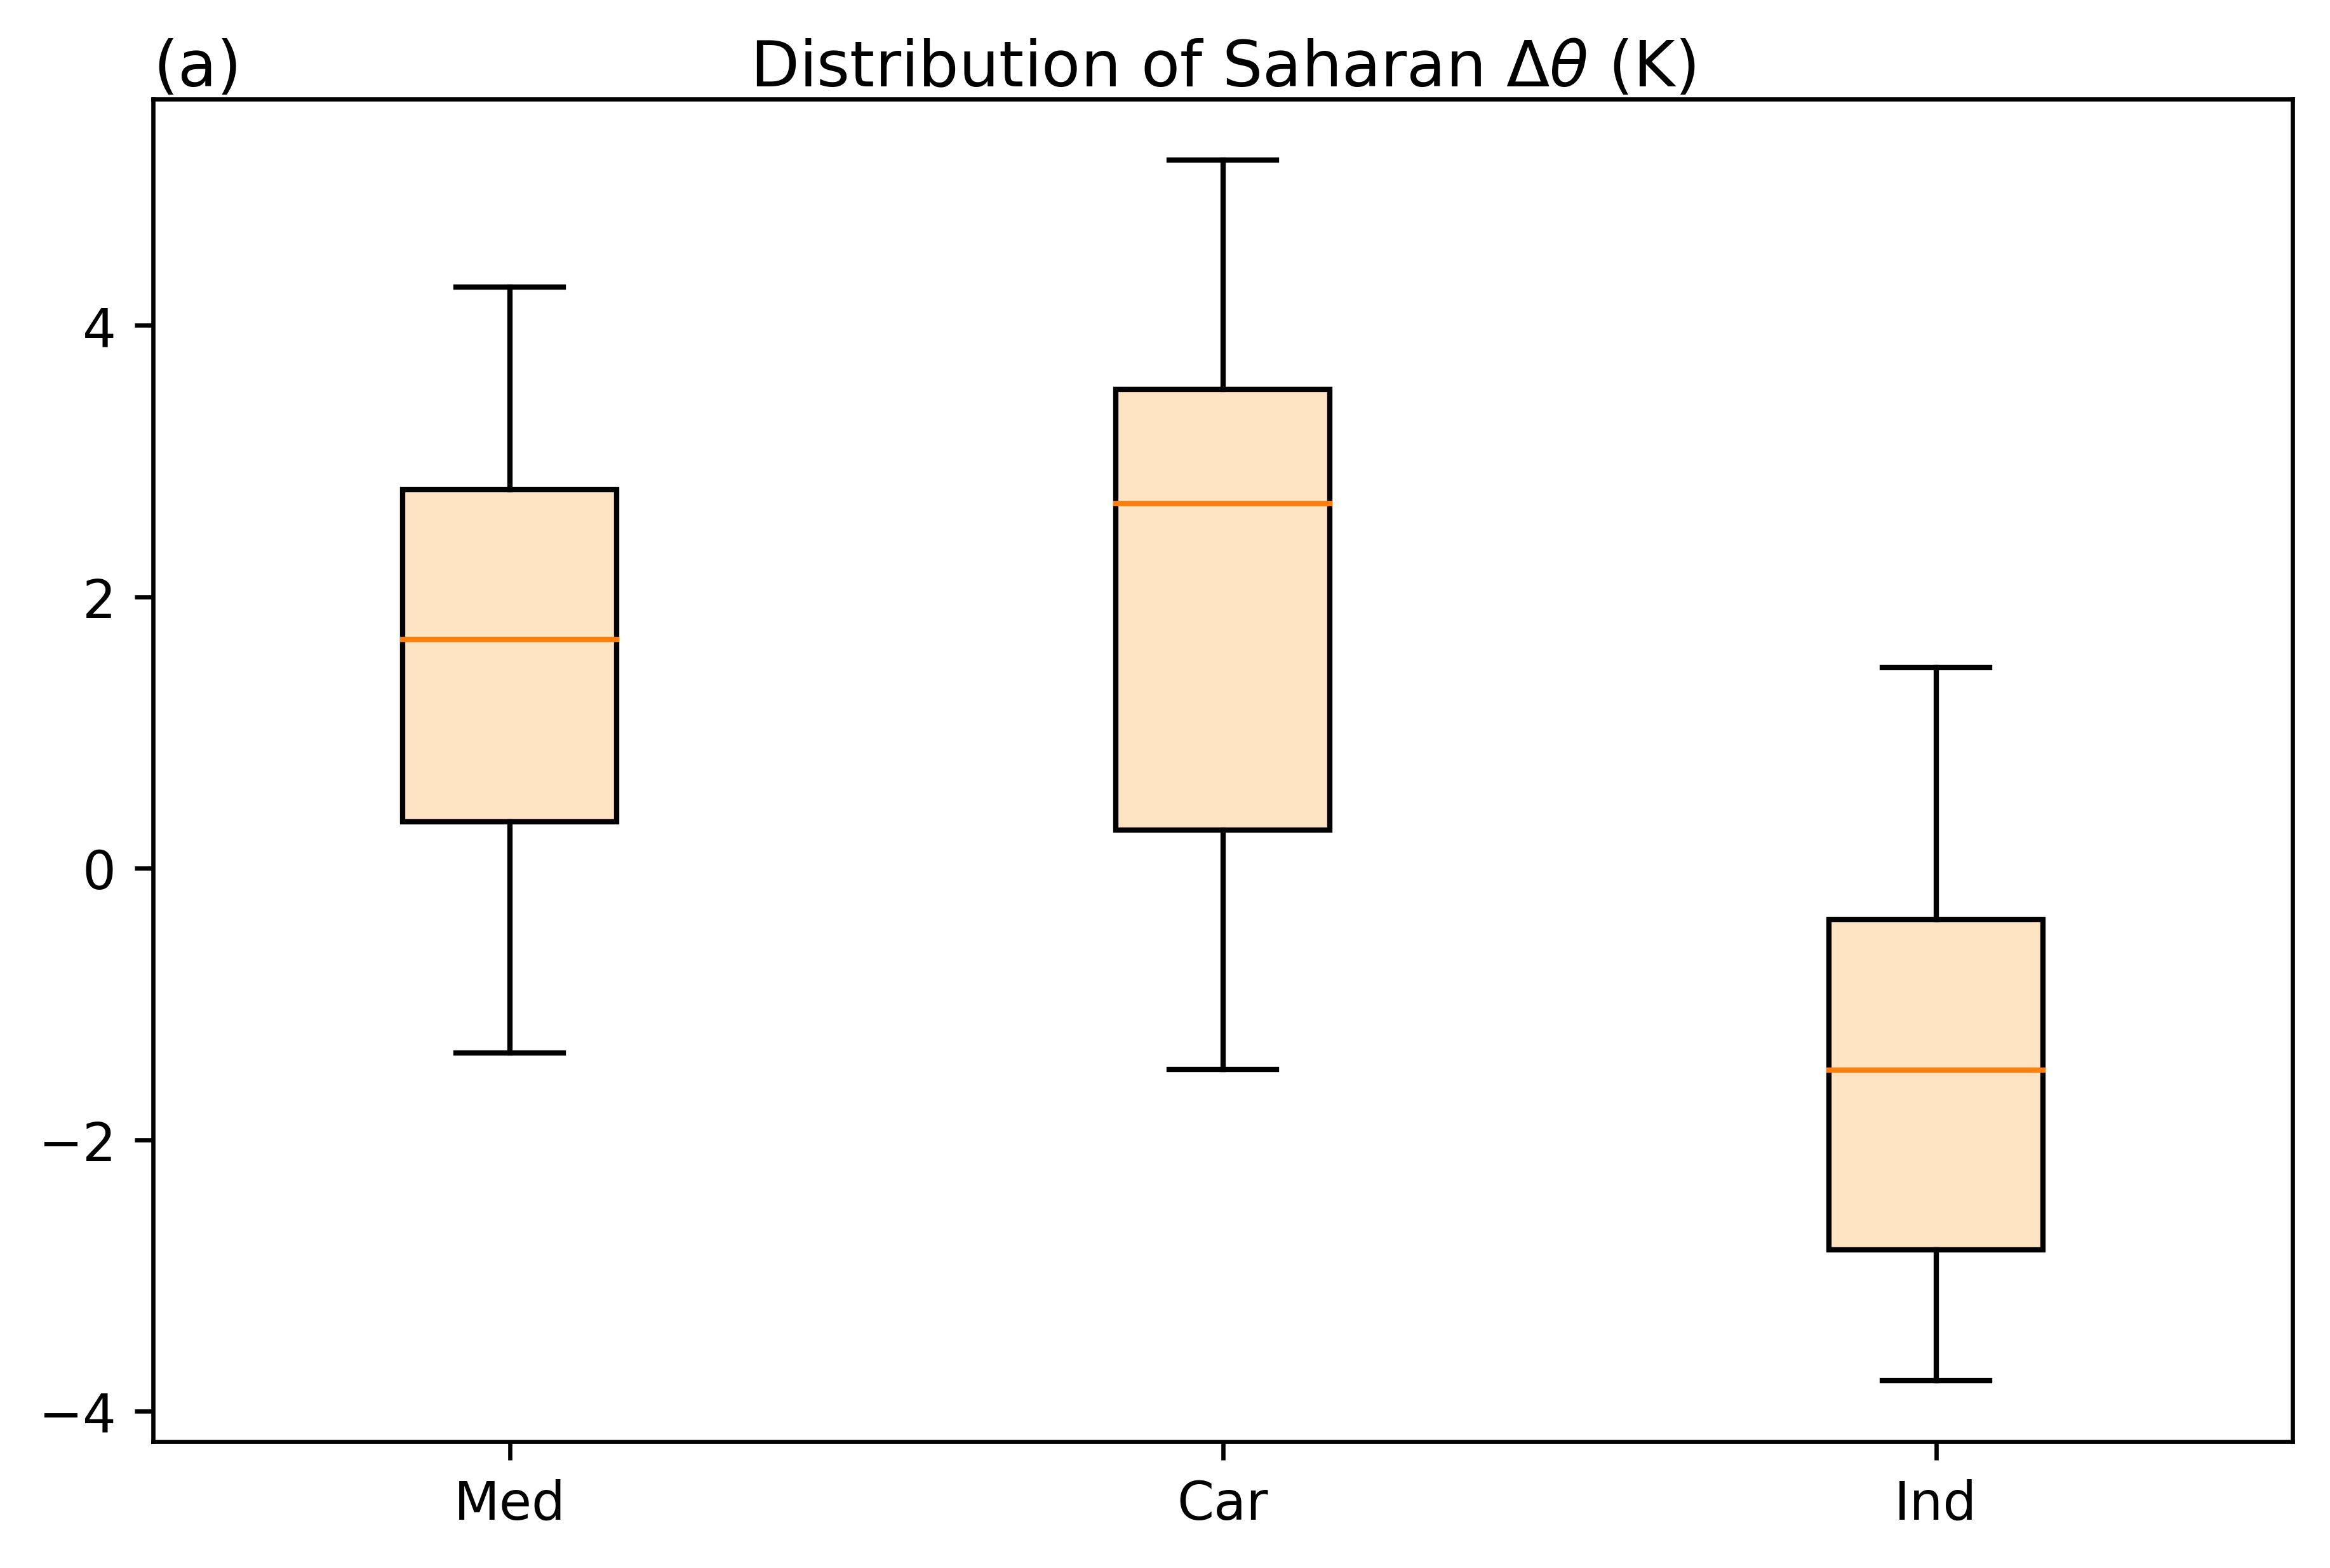

In [23]:
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])
data1=Med_pot
data2=Car_pot
data3=Ind_pot
data=[data1,data2,data3]
labels = ['Med', 'Car', 'Ind']
ax.boxplot(data,
           patch_artist=True, boxprops={'facecolor': 'bisque'},showfliers=False
           )
ax.set_xticks([y + 1 for y in range(len(data))],
                  labels=['Med', 'Car', 'Ind'])
ax.set_title(r'Distribution of Saharan $\Delta \theta$ (K)',pad=1)
ax.set_title('(a)',pad=1,loc='left')

Text(0, 0.5, 'Probability Density Function')

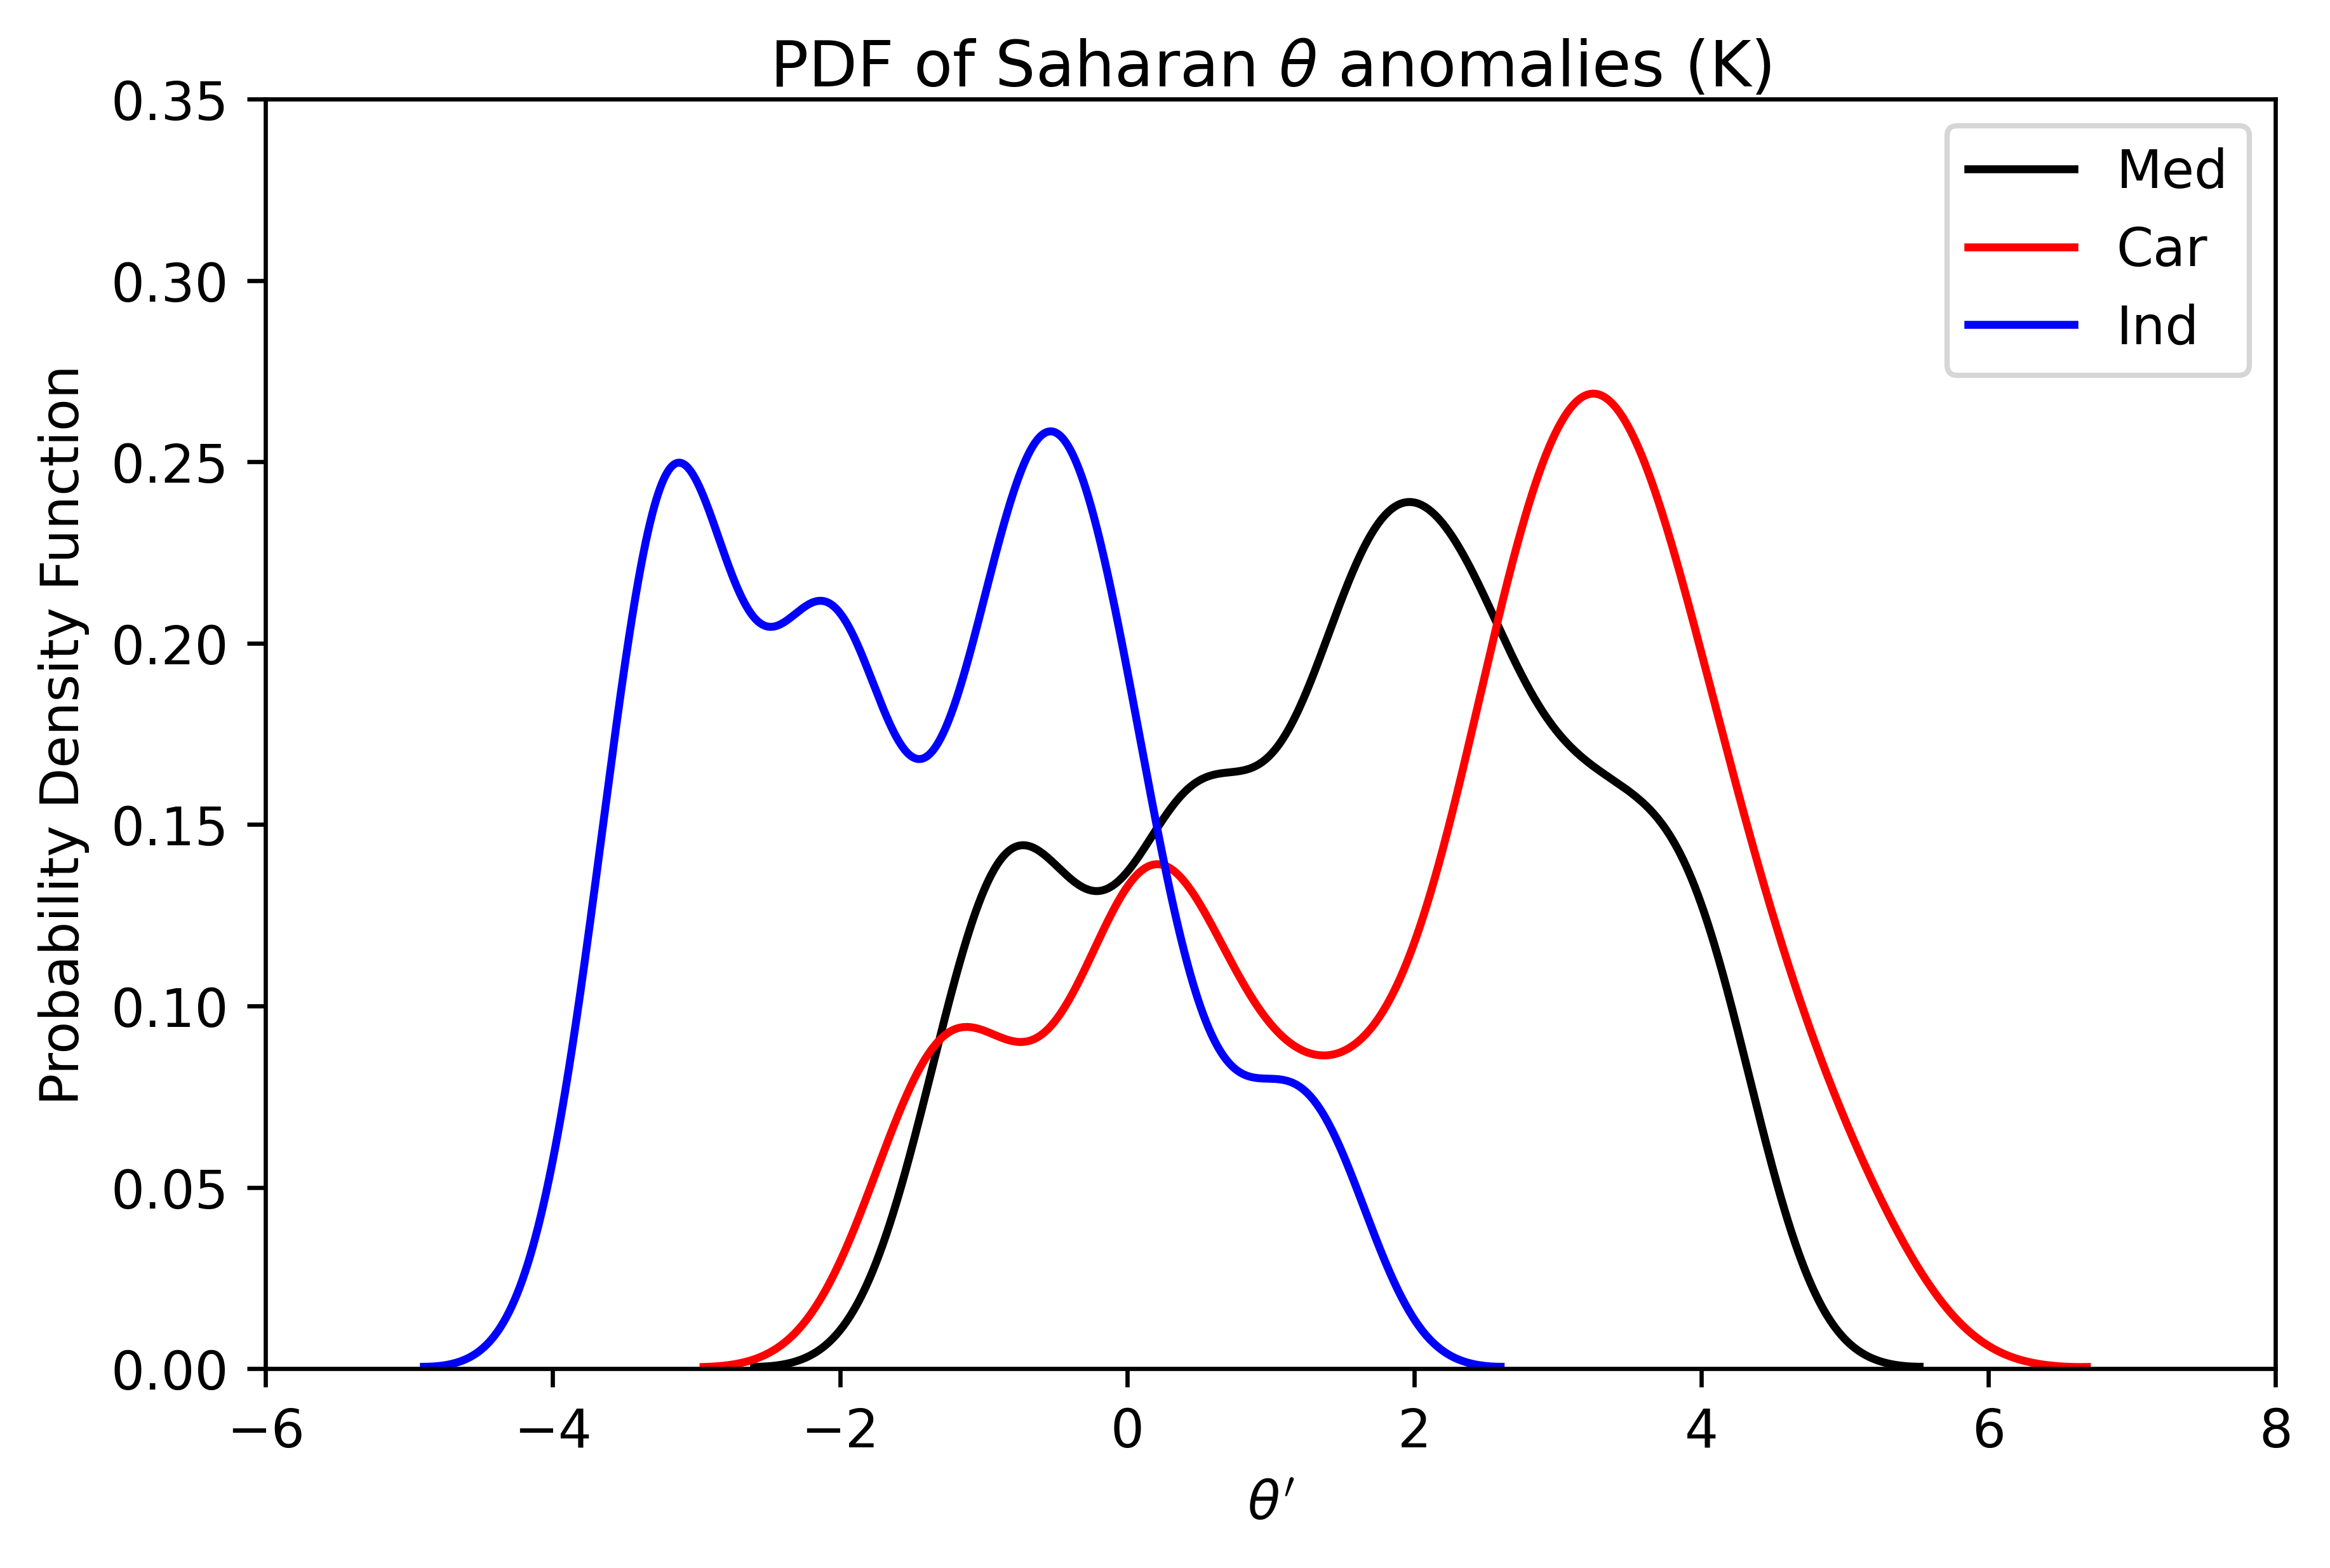

In [78]:
# def get_pdf(x):
#     kde = gaussian_kde(x)

#     # x 轴范围（稍微留点边）
#     x_min, x_max = np.percentile(x, [1, 99])
#     xx = np.linspace(x_min, x_max, 500)

#     pdf = kde(xx)
#     return xx, pdf
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])

# KDE
x=Med_pot
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
# ax.hist(
#     x,
#     bins=20,
#     density=True,
#     color='k',
# #     label="Histogram from samples",
# #     zorder=5,
#     edgecolor="k",
#     alpha=0.5,
# )
ax.plot(kde.support, kde.density,'k',label='Med')
# xx,pdf=get_pdf(x)
# ax.plot(xx, pdf,'k')

x=Car_pot
# ax.hist(
#     x,
#     bins=20,
#     density=True,
#     color='r',
# #     label="Histogram from samples",
# #     zorder=5,
#     edgecolor="r",
#     alpha=0.5,
# )
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'r',label='Car')

x=Ind_pot
# ax.hist(
#     x,
#     bins=20,
#     density=True,
#     color='g',
# #     label="Histogram from samples",
# #     zorder=5,
#     edgecolor="g",
#     alpha=0.5,
# )
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'b',label='Ind')
ax.set_ylim([0,0.35])
ax.set_xlim([-6,8])
ax.legend(loc='best')
ax.set_title(r'PDF of Saharan $\theta$ anomalies (K)',pad=1)
ax.set_xlabel(r'$\theta^{\prime}$')
ax.set_ylabel('Probability Density Function')

In [59]:
np.trapz(kde.density,kde.support)

0.9999979634097782

In [79]:
np.mean(Med_pot>0)

<xarray.DataArray 'pot' ()>
array(0.80410448)

In [80]:
np.mean(Car_pot>0)

<xarray.DataArray 'pot' ()>
array(0.84701493)

In [81]:
np.mean(Ind_pot<0)

<xarray.DataArray 'pot' ()>
array(0.84141791)

Text(0.0, 1.0, '(b)')

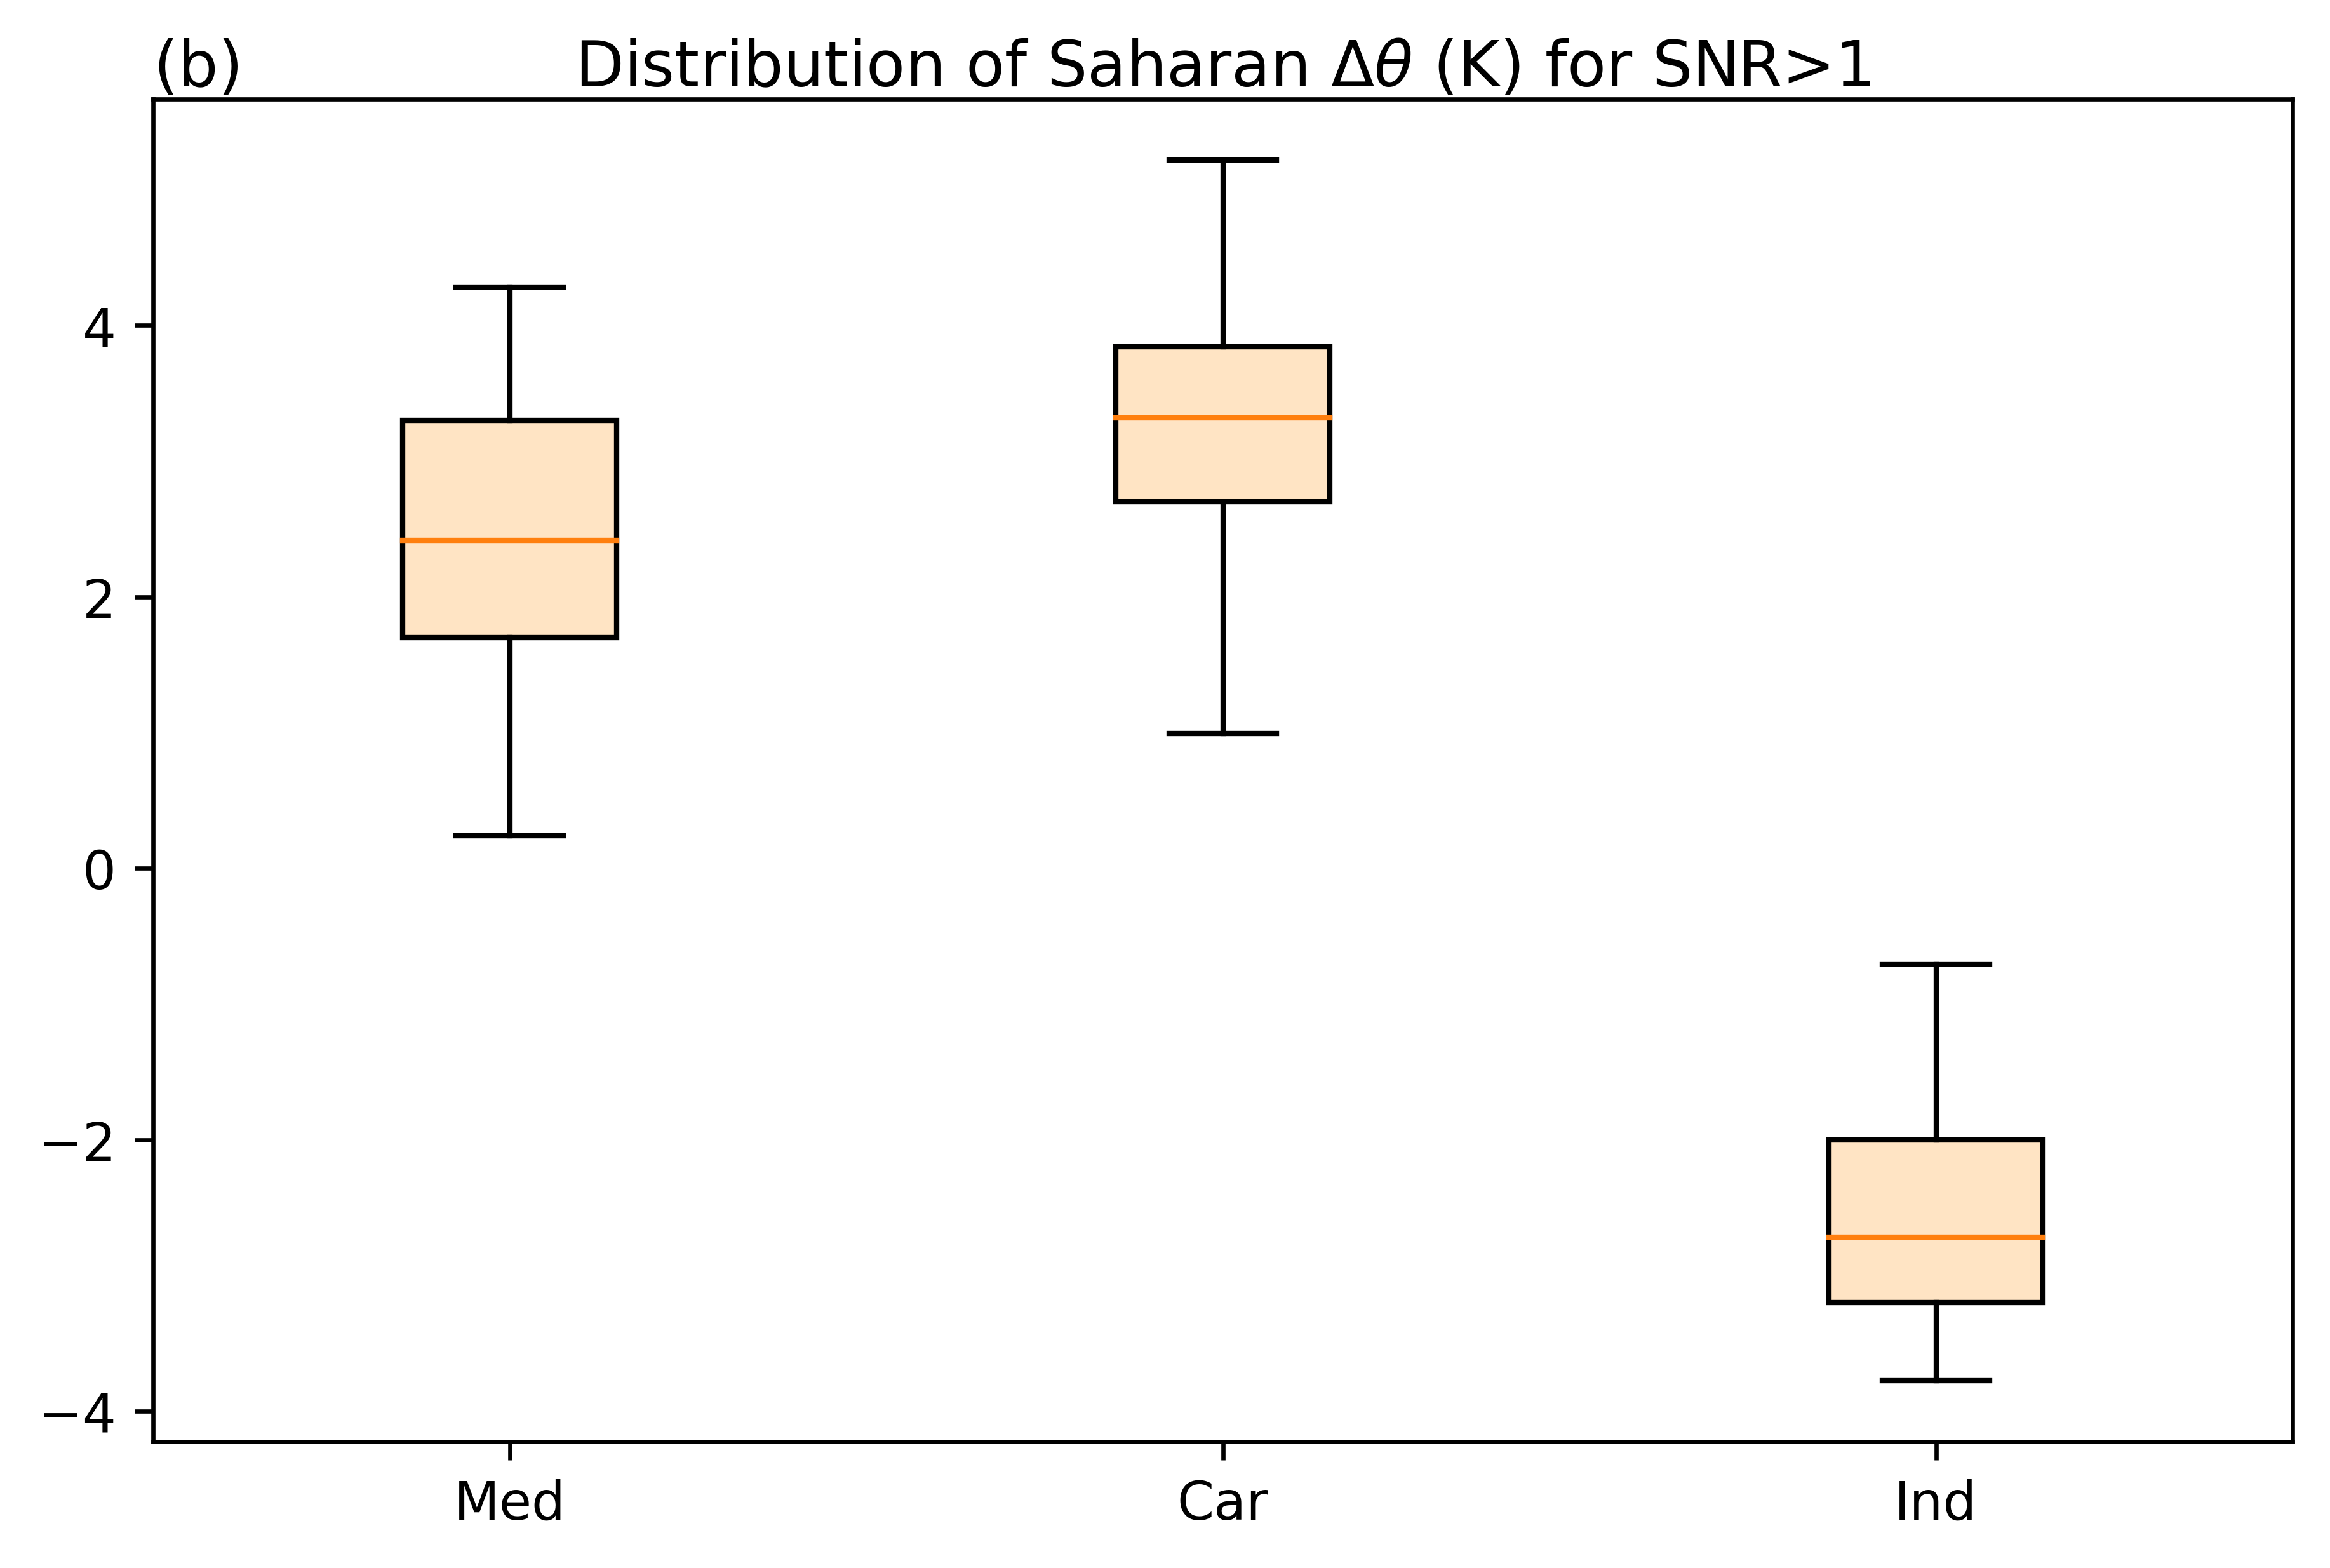

In [20]:
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])
data1=Med_pot_sample
data2=Car_pot_sample
data3=Ind_pot_sample
data=[data1,data2,data3]
labels = ['Med', 'Car', 'Ind']

flierprops = dict(marker='o', markersize=5,#markerfacecolor='black', 
                  markeredgecolor='k')
ax.boxplot(data,
           patch_artist=True, boxprops={'facecolor': 'bisque'},showfliers=False
           )
ax.set_xticks([y + 1 for y in range(len(data))],
                  labels=['Med', 'Car', 'Ind'])
ax.set_title(r'Distribution of Saharan $\Delta \theta$ (K) for SNR>1',pad=1)
ax.set_title('(b)',pad=1,loc='left')

In [91]:
np.mean(Med_pot_sample>0)

<xarray.DataArray 'pot' ()>
array(0.9469914)

In [92]:
np.mean(Car_pot_sample>0)

<xarray.DataArray 'pot' ()>
array(0.98171589)

In [93]:
np.mean(Ind_pot_sample<0)

<xarray.DataArray 'pot' ()>
array(1.)

Text(0, 0.5, 'Probability Density Function')

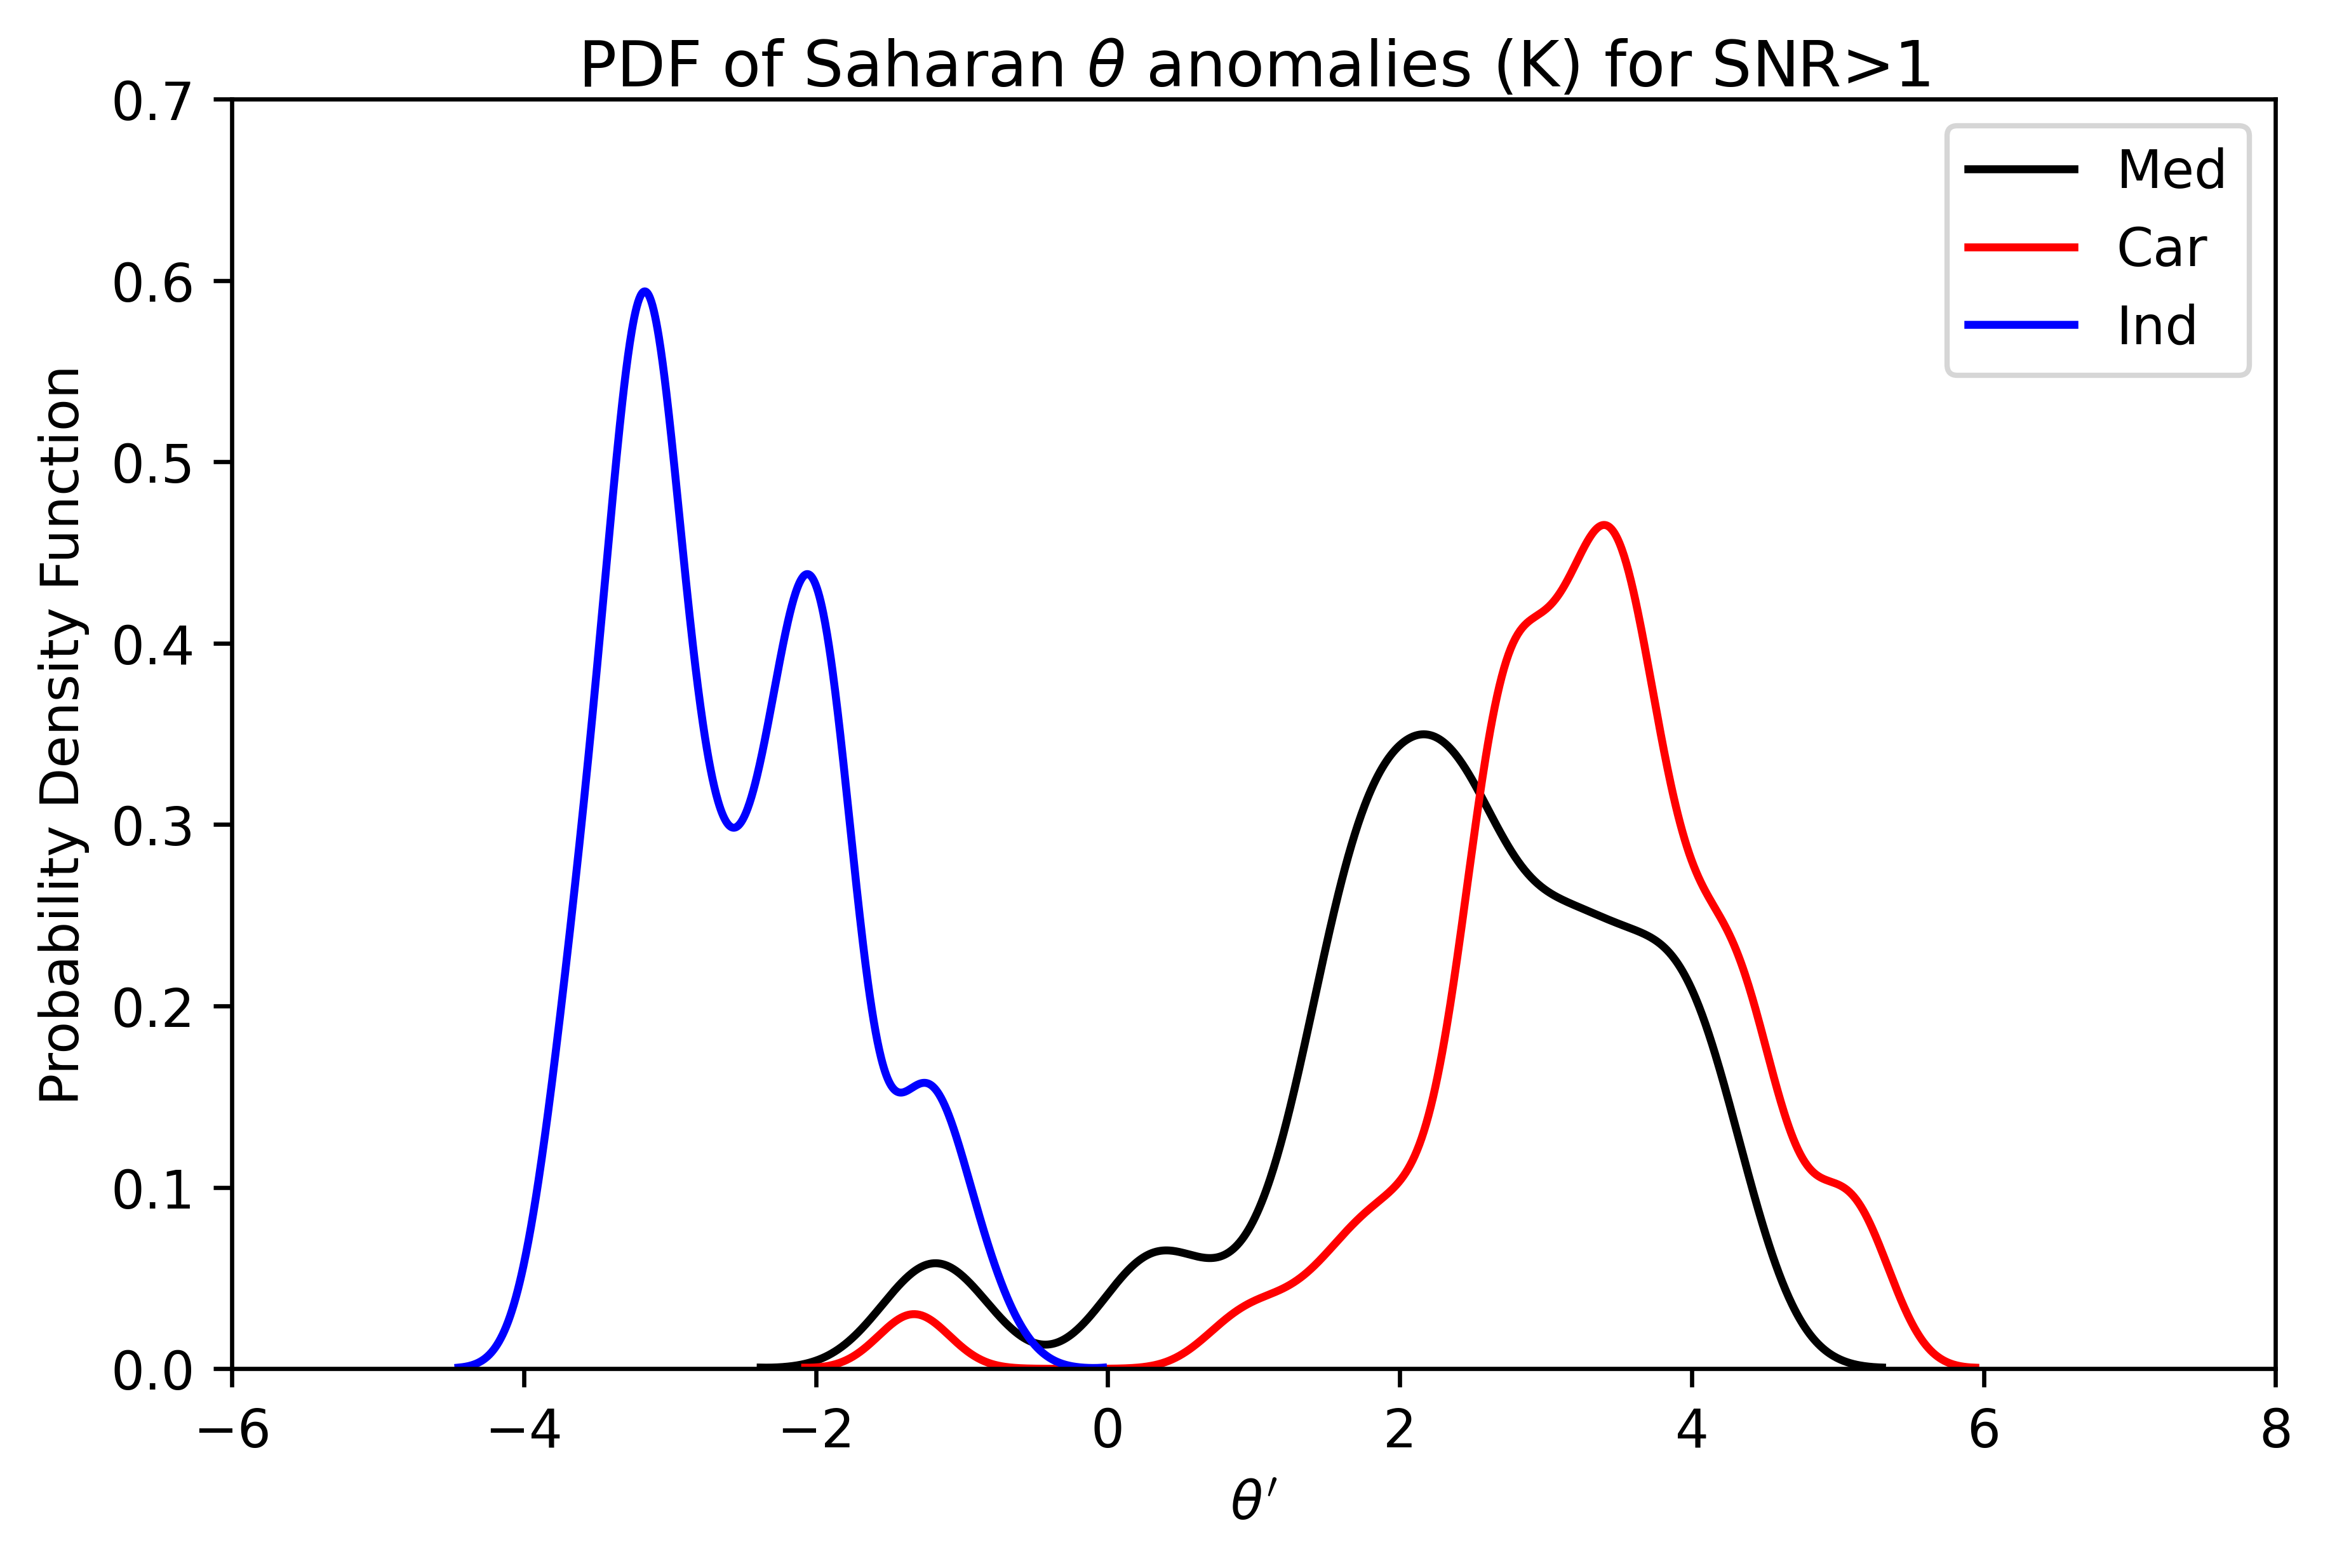

In [84]:
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])

# KDE
x=Med_pot_sample
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
# ax.hist(
#     x,
#     bins=20,
#     density=True,
#     color='k',
# #     label="Histogram from samples",
# #     zorder=5,
#     edgecolor="k",
#     alpha=0.5,
# )
ax.plot(kde.support, kde.density,'k',label='Med')
# xx,pdf=get_pdf(x)
# ax.plot(xx, pdf,'k')

x=Car_pot_sample
# ax.hist(
#     x,
#     bins=20,
#     density=True,
#     color='r',
# #     label="Histogram from samples",
# #     zorder=5,
#     edgecolor="r",
#     alpha=0.5,
# )
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'r',label='Car')

x=Ind_pot_sample
# ax.hist(
#     x,
#     bins=20,
#     density=True,
#     color='g',
# #     label="Histogram from samples",
# #     zorder=5,
#     edgecolor="g",
#     alpha=0.5,
# )
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'b',label='Ind')
ax.set_ylim([0,0.7])
ax.set_xlim([-6,8])
ax.legend(loc='best')
ax.set_title(r'PDF of Saharan $\theta$ anomalies (K) for SNR>1',pad=1)
ax.set_xlabel(r'$\theta^{\prime}$')
ax.set_ylabel('Probability Density Function')

Text(0.0, 1.0, '(b)')

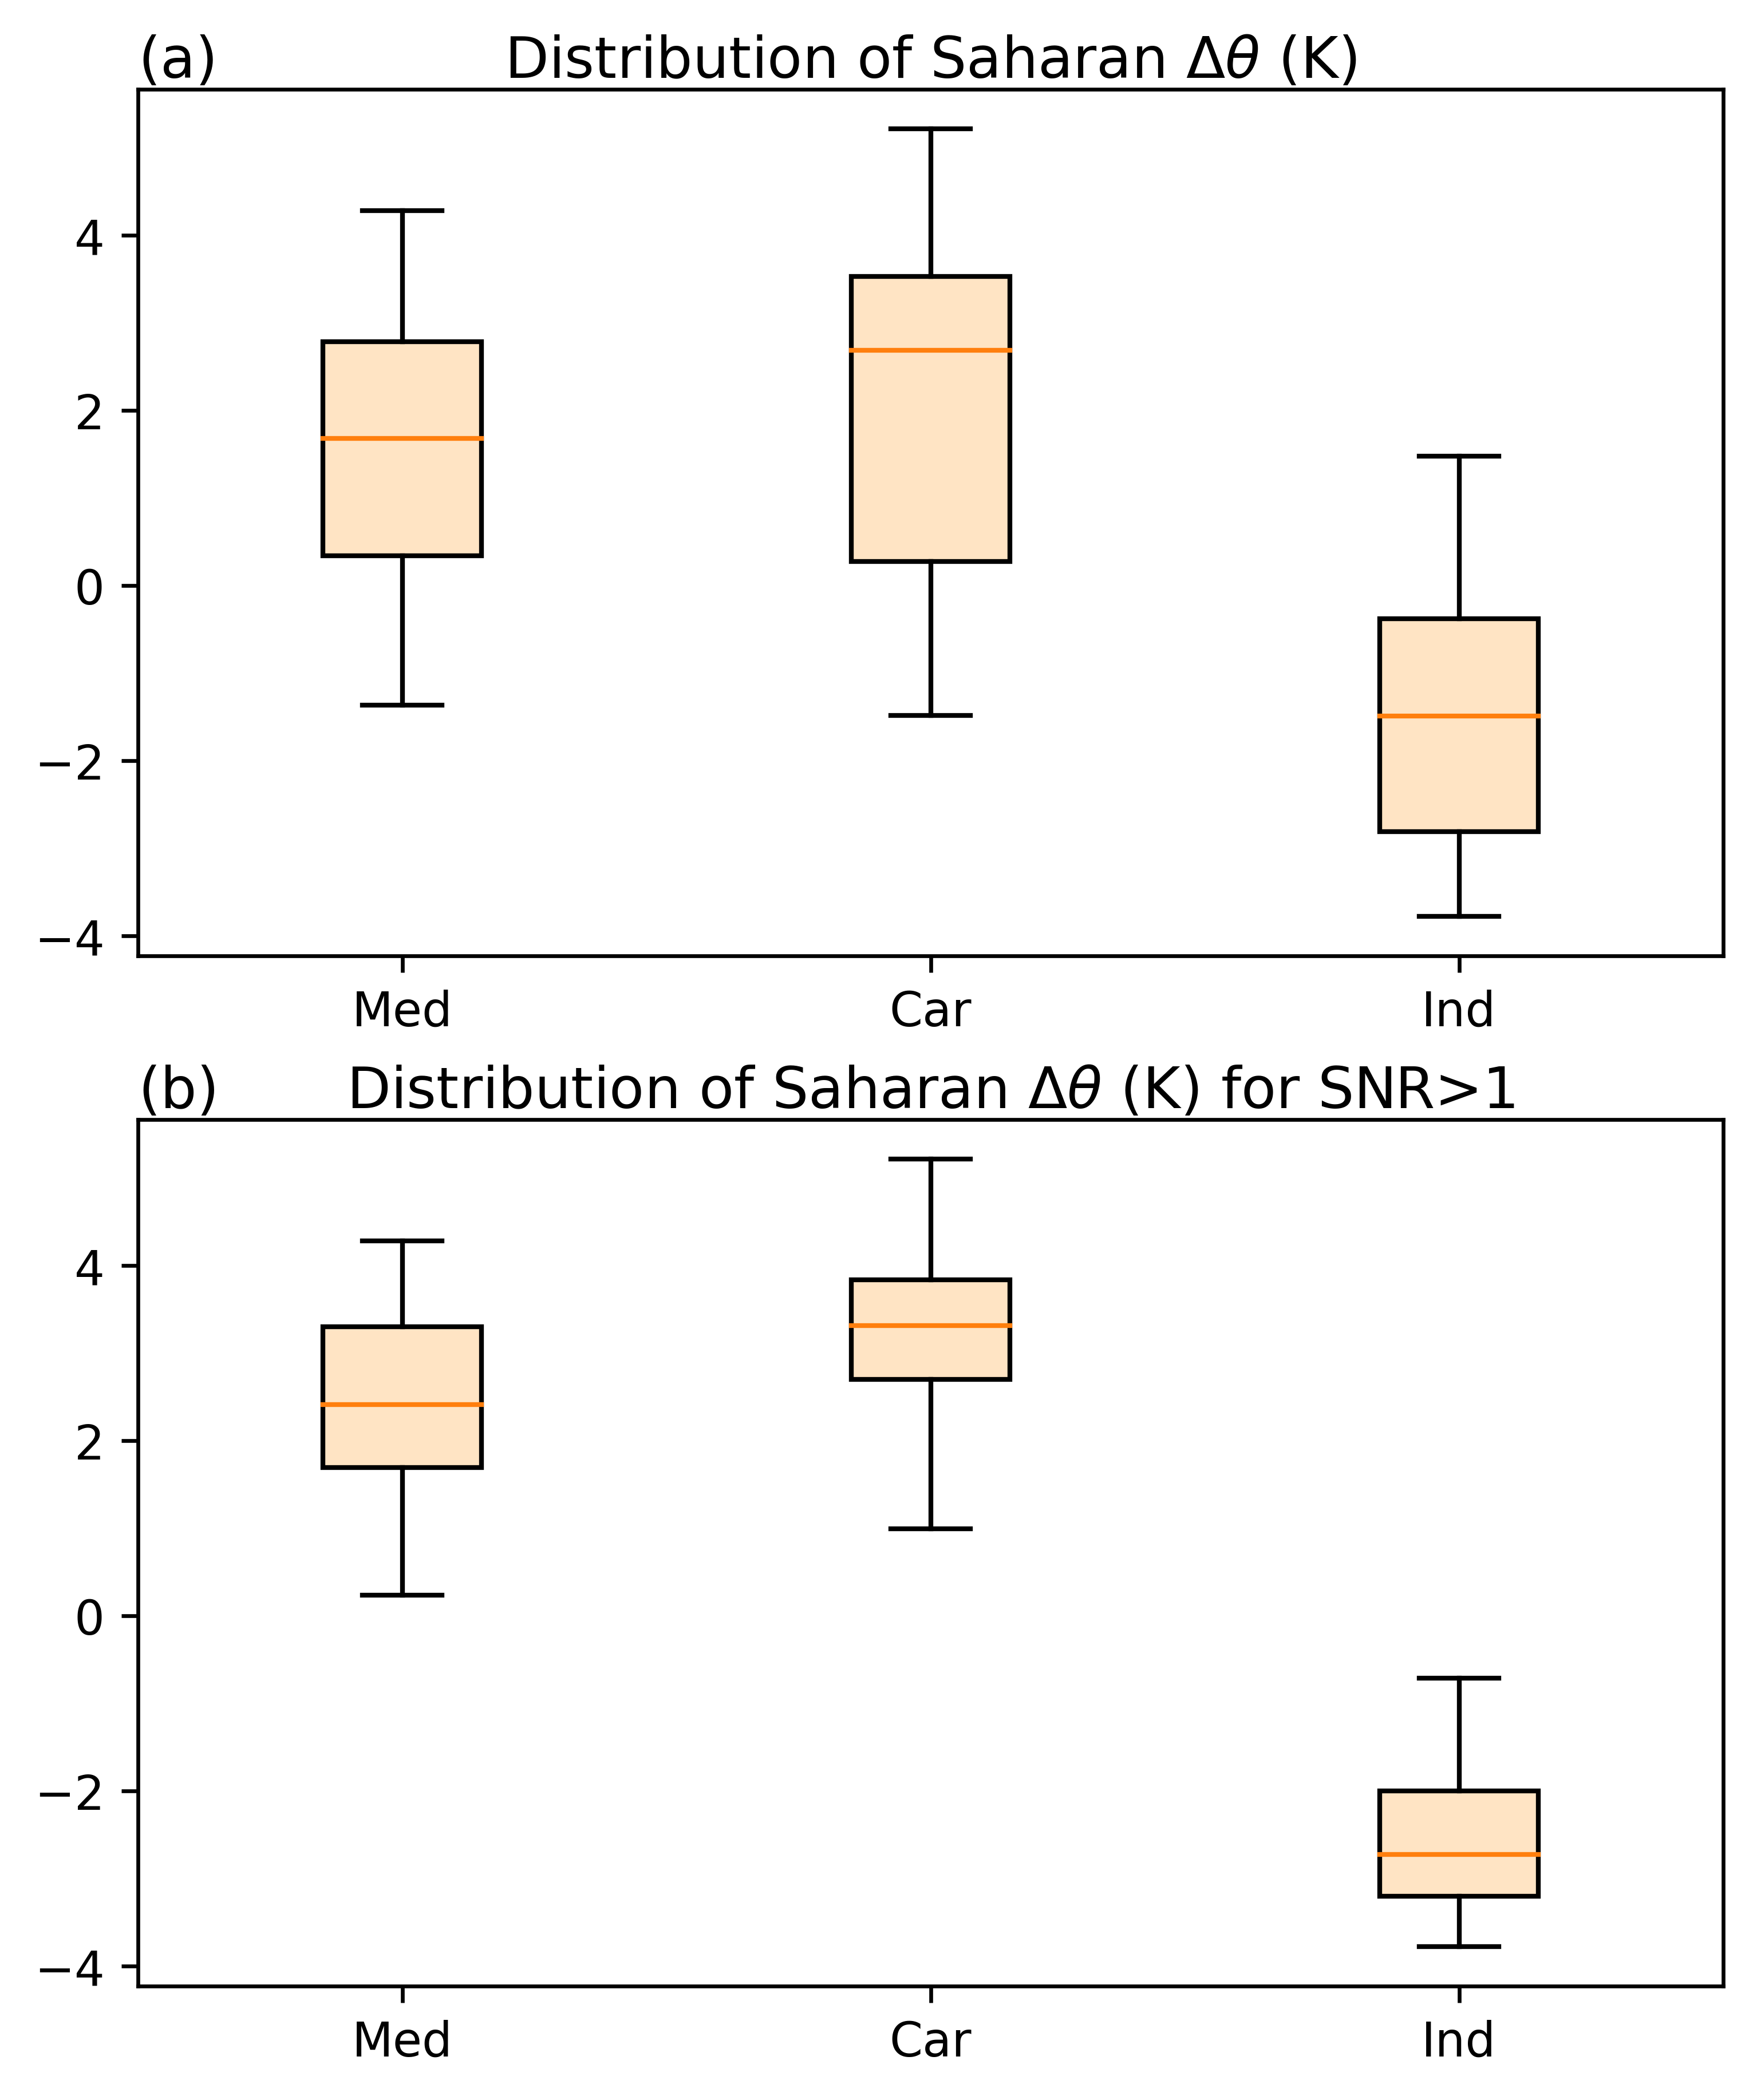

In [22]:
fig = plt.figure(figsize=(5, 6),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=2)

ax = fig.add_subplot(grid[0, 0])
data1=Med_pot
data2=Car_pot
data3=Ind_pot
data=[data1,data2,data3]
labels = ['Med', 'Car', 'Ind']
ax.boxplot(data,
           patch_artist=True, boxprops={'facecolor': 'bisque'},showfliers=False
           )
ax.set_xticks([y + 1 for y in range(len(data))],
                  labels=['Med', 'Car', 'Ind'])
ax.set_title(r'Distribution of Saharan $\Delta \theta$ (K)',pad=1)
ax.set_title('(a)',pad=1,loc='left')


ax = fig.add_subplot(grid[1, 0])
data1=Med_pot_sample
data2=Car_pot_sample
data3=Ind_pot_sample
data=[data1,data2,data3]
labels = ['Med', 'Car', 'Ind']

flierprops = dict(marker='o', markersize=5,#markerfacecolor='black', 
                  markeredgecolor='k')
ax.boxplot(data,
           patch_artist=True, boxprops={'facecolor': 'bisque'},showfliers=False
           )
ax.set_xticks([y + 1 for y in range(len(data))],
                  labels=['Med', 'Car', 'Ind'])
ax.set_title(r'Distribution of Saharan $\Delta \theta$ (K) for SNR>1',pad=1)
ax.set_title('(b)',pad=1,loc='left')

Text(0, 0.5, 'Probability Density Function')

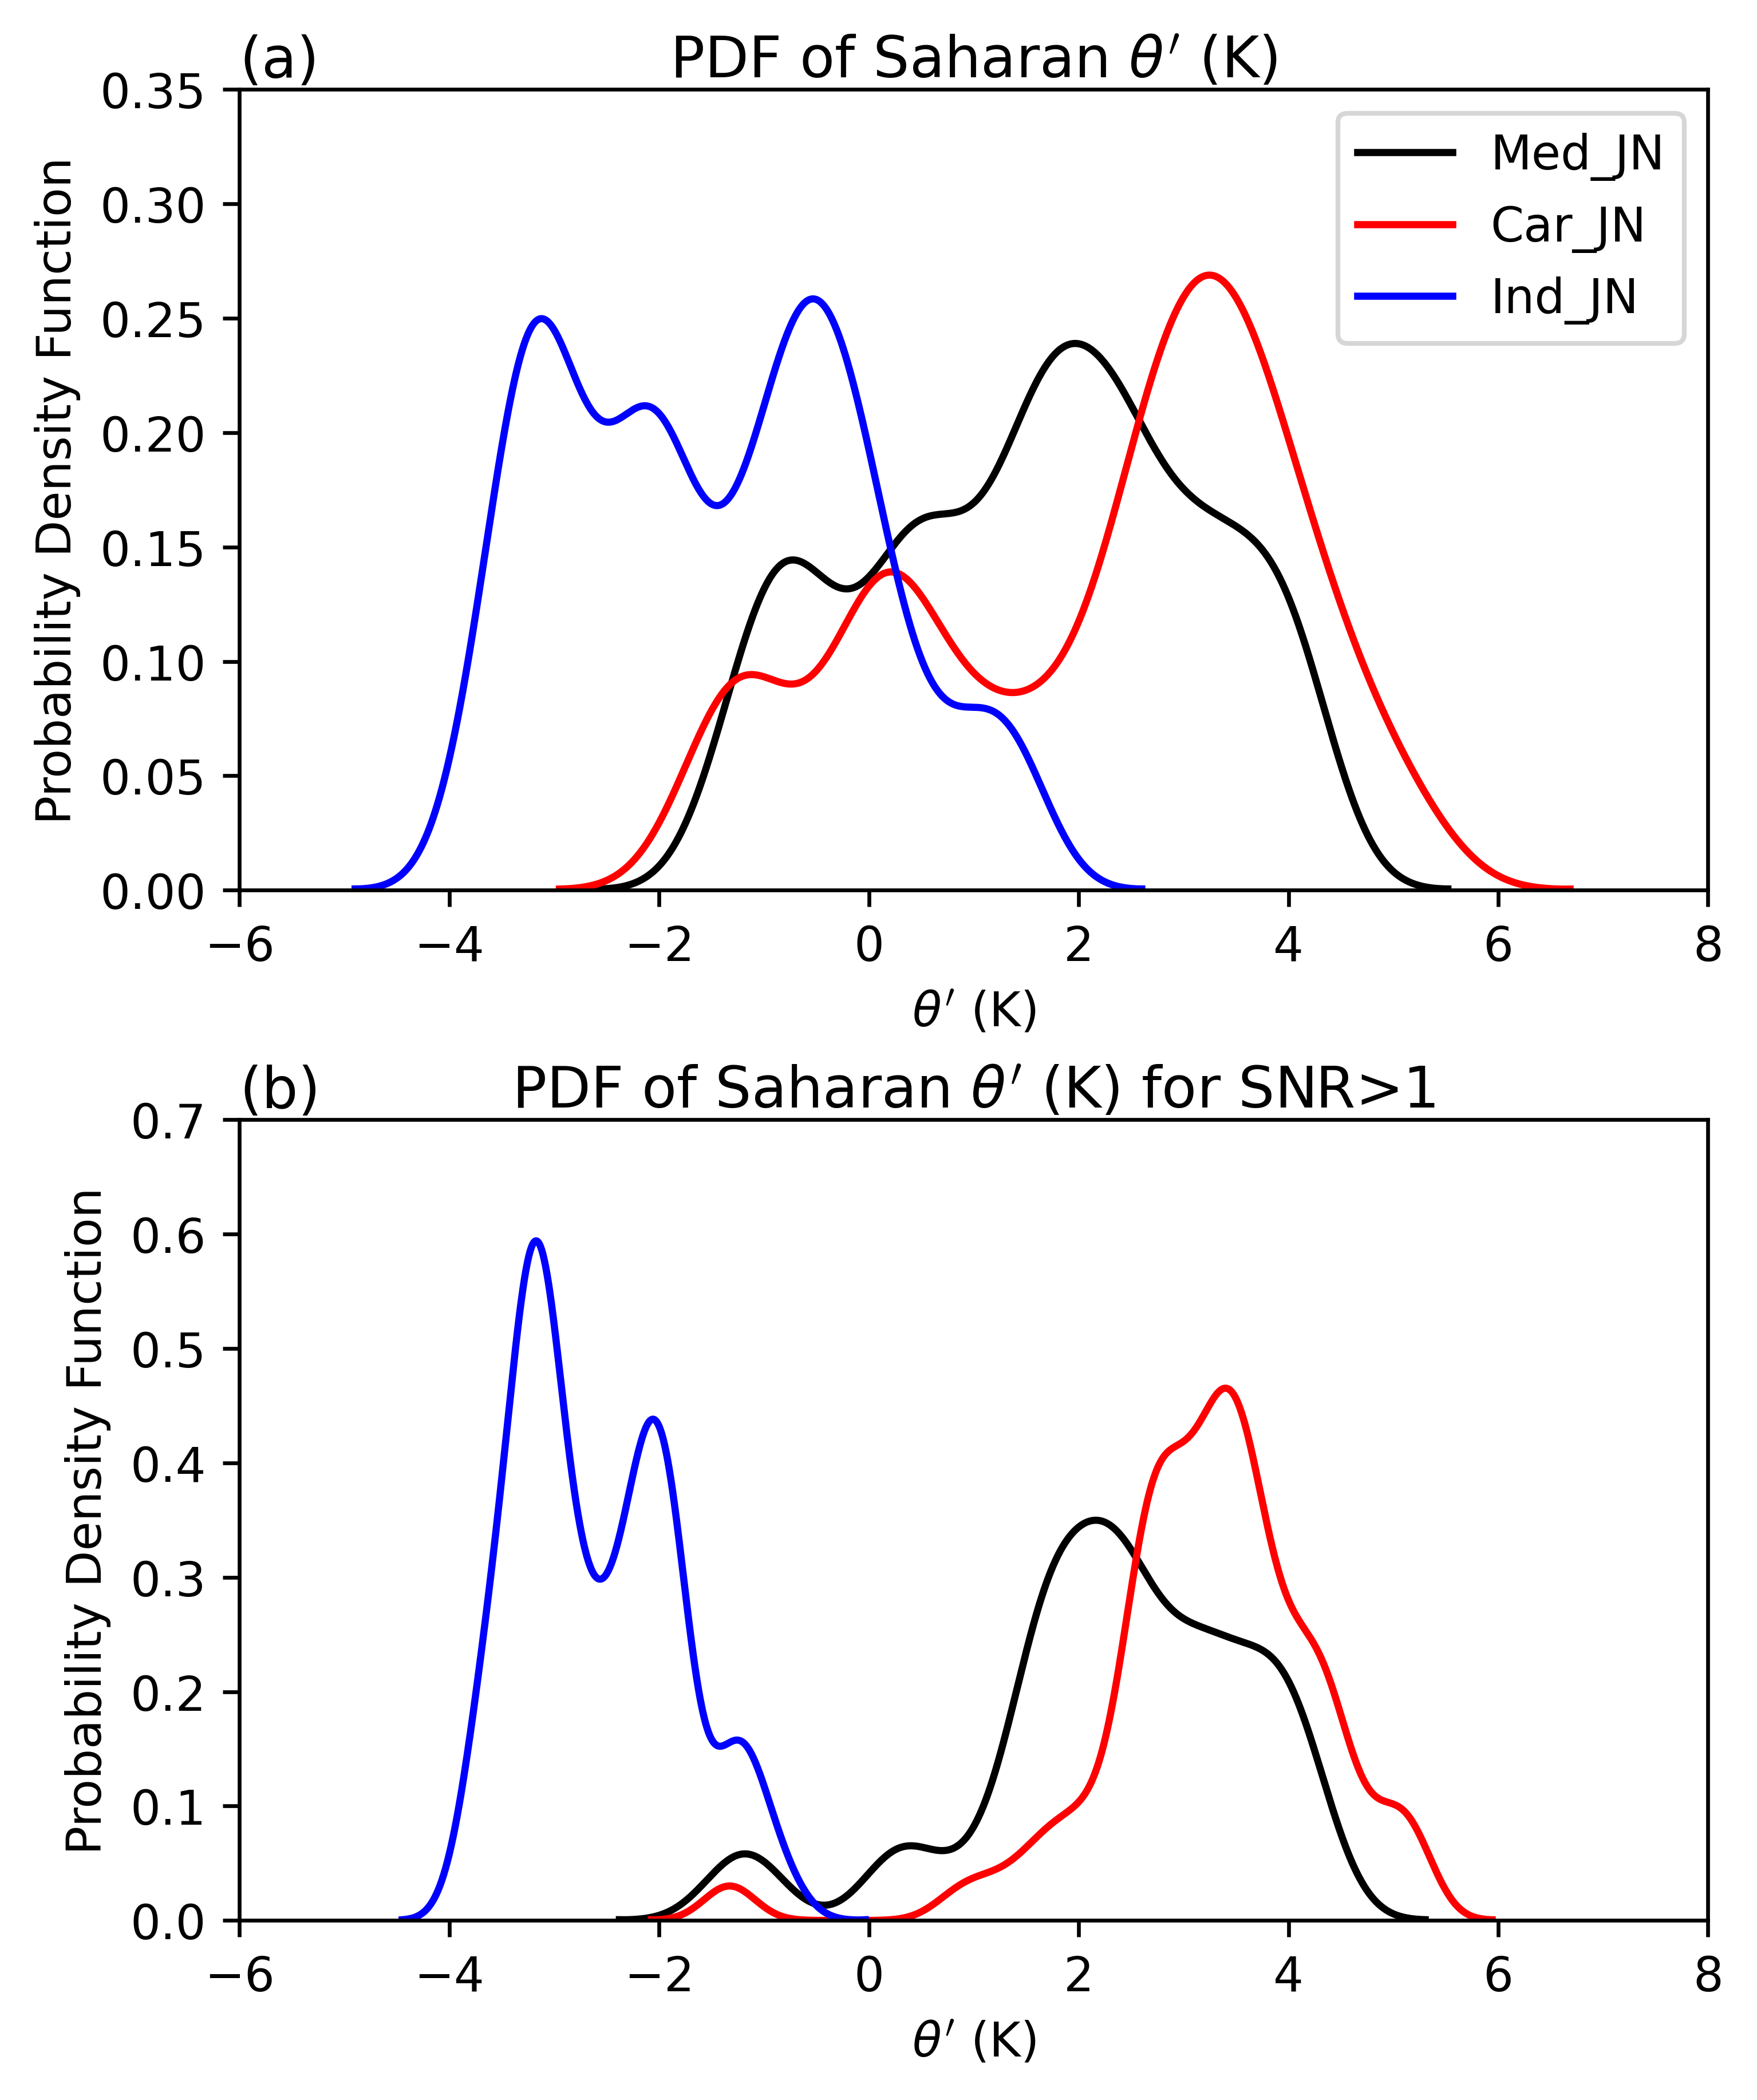

In [94]:
fig = plt.figure(figsize=(5, 6),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=2)

ax = fig.add_subplot(grid[0, 0])

# KDE
x=Med_pot
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'k',label='Med_JN')


x=Car_pot
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'r',label='Car_JN')

x=Ind_pot
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'b',label='Ind_JN')
ax.set_ylim([0,0.35])
ax.set_xlim([-6,8])
ax.legend(loc='best')
ax.set_title(r'PDF of Saharan $\theta^{\prime}$ (K)',pad=1)
ax.set_title('(a)',pad=1,loc='left')
ax.set_xlabel(r'$\theta^{\prime}$ (K)')
ax.set_ylabel('Probability Density Function')

ax = fig.add_subplot(grid[1, 0])

# KDE
x=Med_pot_sample
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'k',label='Med')


x=Car_pot_sample
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'r',label='Car')

x=Ind_pot_sample
kde = sm.nonparametric.KDEUnivariate(x)
kde.fit()  # Estimate the densities
ax.plot(kde.support, kde.density,'b',label='Ind')
ax.set_ylim([0,0.7])
ax.set_xlim([-6,8])
# ax.legend(loc='best')
ax.set_title(r'PDF of Saharan $\theta^{\prime}$ (K) for SNR>1',pad=1)
ax.set_title('(b)',pad=1,loc='left')
ax.set_xlabel(r'$\theta^{\prime}$ (K)')
ax.set_ylabel('Probability Density Function')

## Calculate the total warming (cooling) fraction

In [159]:
def total_frac1(dtheta,snr,dadv):
    ## For Med and Car
    # masks
    warm = dtheta > 0
    E = snr > 1
    A = dadv > 0

    # total positive warming (denominator)
    total_warm = dtheta.where(warm).sum("time", skipna=True)

    # positive warming that occurs when (SNR>1) AND (ΔAdv>0) (numerator)
#     warm_EA = dtheta.where(warm & E & A).sum("time", skipna=True)
#     warm_EA = dtheta.where(warm & E ).sum("time", skipna=True)
    warm_EA = dtheta.where(E).sum("time", skipna=True)

    # contribution fraction
    contribution_EA = (warm_EA / total_warm).rename("contribution_SNRgt1_and_dadvgt0")

    contribution_EA
    
    return contribution_EA

def total_frac2(dtheta,snr,dadv):
    ## For Ind
    # masks
    cold = dtheta < 0
    E = snr > 1
    A = dadv < 0

    # total positive cooling (denominator)
    total_cold = dtheta.where(cold).sum("time", skipna=True)

    # positive warming that occurs when (SNR>1) AND (ΔAdv>0) (numerator)
#     cold_EA = dtheta.where(cold & E & A).sum("time", skipna=True)
#     cold_EA = dtheta.where(cold & E ).sum("time", skipna=True)
    cold_EA = dtheta.where(E).sum("time", skipna=True)
#     cold_EA = dtheta.where(E&A).sum("time", skipna=True)

    # contribution fraction
    contribution_EA = (cold_EA / total_cold).rename("contribution_SNRgt1_and_dadvgt0")

    contribution_EA
    
    return contribution_EA

dtheta=Med_pot
snr   =snr_Med_nonan
dadv  =Med_Tadv
contribution_Med=total_frac1(dtheta,snr,dadv)

dtheta=Car_pot
snr   =snr_Car_nonan
dadv  =Car_Tadv
contribution_Car=total_frac1(dtheta,snr,dadv)

dtheta=Ind_pot
snr   =snr_Ind_nonan
dadv  =Ind_Tadv
contribution_Ind=total_frac2(dtheta,snr,dadv)
contribution_Ind

<xarray.DataArray 'contribution_SNRgt1_and_dadvgt0' ()>
array(0.86684572)

In [160]:
contribution_Car

<xarray.DataArray 'contribution_SNRgt1_and_dadvgt0' ()>
array(0.94057284)

In [161]:
contribution_Med

<xarray.DataArray 'contribution_SNRgt1_and_dadvgt0' ()>
array(0.88688662)